|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>ANNs<h1>|
|<h2>Lecture:</h2>|<h1><b>ANN for regression<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
%matplotlib widget 

# import libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
print("cuda available:", torch.cuda.is_available())
print("cuda devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("current device index:", torch.cuda.current_device())
    print("device name:", torch.cuda.get_device_name(torch.cuda.current_device()))

cuda available: True
cuda devices: 1
current device index: 0
device name: NVIDIA GeForce RTX 5060 Ti


In [3]:
def create_data(m=1, N=30, noise_level=0.5):
    x = torch.randn(N,1)
    y = m * x + torch.randn(N,1)*noise_level
    return x, y

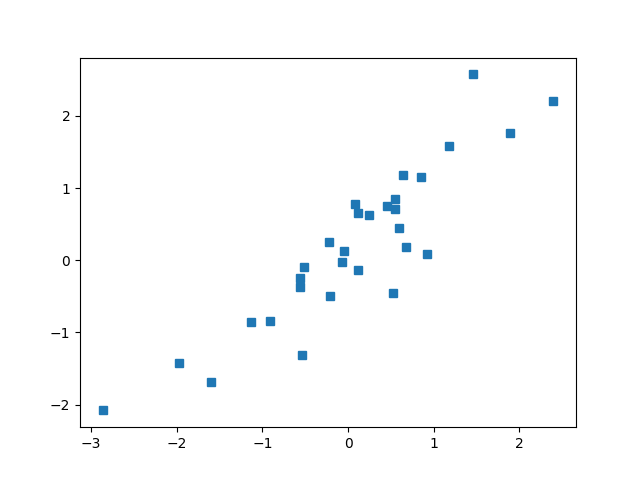

In [4]:
# create data - just for plotting
x, y = create_data()

# and plot
plt.figure()
plt.plot(x,y,'s')
plt.show()

In [5]:
def build_and_train_model(x, y, learning_rate=0.05, training_epochs=500):
    """
    Train a simple two-layer ANN for regression.

    Args:
        x (torch.Tensor): Input features of shape (N, 1), float tensor.
        y (torch.Tensor): Target values of shape (N, 1), float tensor.
        learning_rate (float): SGD learning rate.
        training_epochs (int): Number of training epochs.

    Returns:
        (torch.nn.Sequential, torch.Tensor, torch.Tensor):
            - Trained model.
            - Per-epoch losses (tensor of length training_epochs).
            - Final test loss (scalar tensor).
    """
    
    # build model
    ANNreg = nn.Sequential(
        nn.Linear(1,1),  # input layer
        nn.ReLU(),       # activation function
        nn.Linear(1,1)   # output layer
        )
    
    # define loss function and optimizer
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(ANNreg.parameters(), lr=learning_rate)
    
    # training loop
    losses = torch.zeros(training_epochs)
    for epochi in range(training_epochs):
        y_pred = ANNreg(x)  # forward pass: compute predicted y
        loss = loss_fn(y_pred, y)  # compute loss
        losses[epochi] = loss.item()
        
        # zero gradients, perform a backward pass, and update the weights.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # manually compute losses (usually train and predict would be separated!)
    predictions = ANNreg(x)  # final forward pass
    testloss = (predictions-y).pow(2).mean()  # final loss (MSE)
        
    return ANNreg, losses, predictions, testloss

In [ ]:
testloss_above_025_cnt = 0
testloss_threshold_value = .25

learningRate = .05
numepochs = 500
ANNreg = None
slope = np.linspace(-2,2,21)
n_repeats = 50
corr_coeff = np.zeros((n_repeats, len(slope)))  # test loss vs slope
losses_vs_slope = np.zeros((n_repeats, len(slope)))  # test loss vs slope
corr_coeff_fn = lambda y_true, y_pred: np.corrcoef(y_true.T,y_pred.T)[0,1]

for n_train in range(n_repeats):
  for m_idx, m in enumerate(slope):
    x, y = create_data(m, N=50)
    ANNreg, losses, predictions, testloss = build_and_train_model(x, y, learning_rate=learningRate, training_epochs=numepochs)
    if testloss.item() > testloss_threshold_value:
        testloss_above_025_cnt += 1
    corr_coeff[n_train, m_idx] = corr_coeff_fn(y, predictions.detach())
    losses_vs_slope[n_train, m_idx] = testloss.item()
print(f'Number of times loss > {testloss_threshold_value} over {n_repeats} runs: {testloss_above_025_cnt/n_repeats}')

corr_coeff = np.nan_to_num(corr_coeff, nan=0.0)

/home/nuke/Documents/dev/.work_py_venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/nuke/Documents/dev/.work_py_venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Number of times loss > 0.25 over 50 runs: 12.6


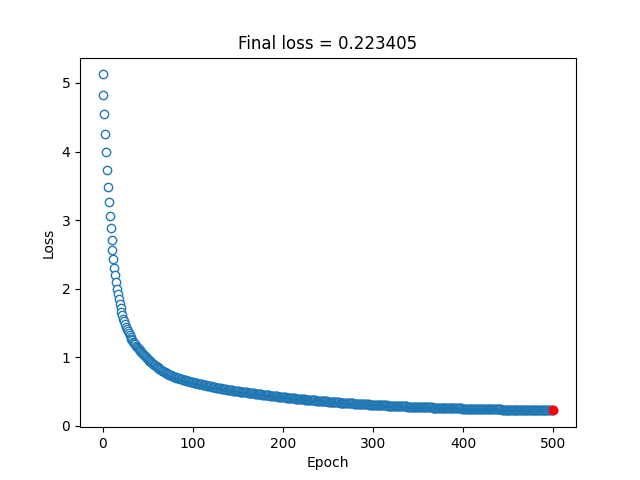

In [7]:
# show the losses

# manually compute losses
# final forward pass
predictions = ANNreg(x)

# final loss (MSE)
testloss = (predictions-y).pow(2).mean()

plt.figure()
plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.plot(numepochs,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()

In [8]:
testloss.item()

0.22340483963489532

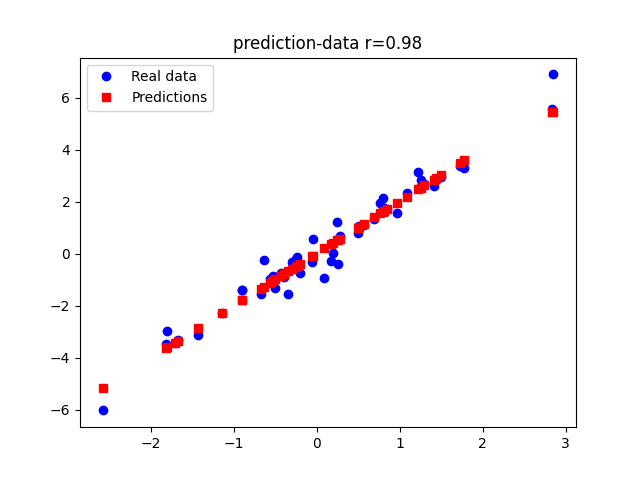

In [9]:
# plot the data - just shows last run
plt.figure()
plt.plot(x,y,'bo',label='Real data')
plt.plot(x,predictions.detach(),'rs',label='Predictions')
plt.title(f'prediction-data r={corr_coeff_fn(y, predictions.detach()):.2f}')
plt.legend()
plt.show()

[[0.95436081 0.9668194  0.93748702 ... 0.94823351 0.         0.94681438]
 [0.94678439 0.95278907 0.93840423 ... 0.         0.96146372 0.97951674]
 [0.97108528 0.9550854  0.94236411 ... 0.9421341  0.96799345 0.96904301]
 ...
 [0.97736719 0.96774094 0.         ... 0.         0.95234736 0.96281992]
 [0.97058346 0.95346795 0.92892574 ... 0.94832379 0.96440767 0.96608762]
 [0.97209788 0.95312583 0.97170238 ... 0.96727134 0.96461196 0.98075325]]
(21,) (21,)


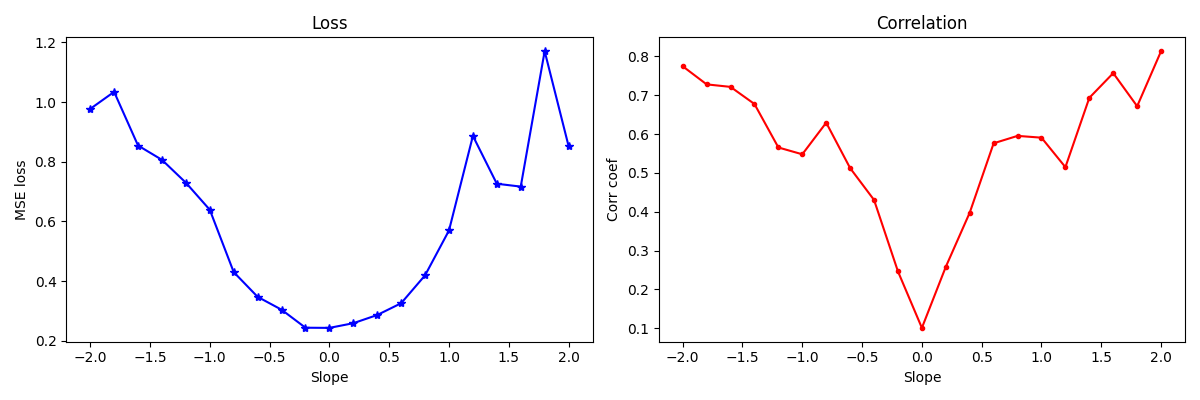

In [15]:
print(corr_coeff)
cc = np.mean(corr_coeff, axis=0)
lv = np.mean(losses_vs_slope, axis=0)
print(np.shape(cc), np.shape(lv))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# losses_vs_slope (first repeat)
axes[0].plot(slope, lv, 'b*-')
axes[0].set_title('Loss')
axes[0].set_xlabel('Slope')
axes[0].set_ylabel('MSE loss')

axes[1].plot(slope, cc, 'r.-')
axes[1].set_title('Correlation')
axes[1].set_xlabel('Slope')
axes[1].set_ylabel('Corr coef')

plt.tight_layout()
plt.show()

# Additional explorations

In [11]:
# 1) How much data is "enough"? Try different values of N and see how low the loss gets.
#    Do you still get low loss ("low" is subjective, but let's say loss<.25) with N=10? N=5?
#
# N = 10 seems to work fine most of the time, but N = 5 often results in loss > .25.
#
# 2) Does your conclusion above depend on the amount of noise in the data? Try changing the noise level
#    by changing the division ("/2") when creating y as x+randn.
#
# No, but it is related to it. More noise makes it harder to get low loss.
#
# 3) Notice that the model doesn't always work well. Put the original code (that is, N=30 and /2 noise)
#    into a function or a for-loop and repeat the training 100 times (each time using a fresh model instance).
#    Then count the number of times the model had a loss>.25.
#
# Test 1: Number of times loss>.25 over 100 runs: 30
# Test 2: Number of times loss>.25 over 100 runs: 25
# Test 3: Number of times loss>.25 over 100 runs: 27